# MuTap — outdoor device bring-up: the recipe

The outdoor close-range chain (`tap::mu::aec_chain_outdoor_preset`) is
**device-calibrated**: its branch basis, calibration constants, filter
geometry and operating plane all encode properties of one particular
loudspeaker-and-mic rig. Today that rig is **simulated**
([`tests/support/outdoor_scenario.h`](../tests/support/outdoor_scenario.h)
— the Rev 6 fixture: a tanh loudspeaker at the moderate drive, the
close-range path at ERL −20). The real device does not exist yet.

This notebook is the **transfer recipe**. It plays a full bring-up
measurement session against the simulated device — sweep, stepped
tones, program material, exactly the recordings you would capture with
the real device's own loudspeaker and mic — and then derives every
device-specific parameter from those recordings alone. **When the real
device exists, point `DATA` at a directory of its recordings (same file
names, raw little-endian float64) and re-run this notebook unchanged.**
The truth columns (known drive, known path) exist only here, for
cross-checking the recipe against the simulator; a real session has no
truth column, which is why every derivation below also states its
self-consistency check.

Honesty rules as everywhere in this repo: the device data is produced
by the C++ fixtures (the source of truth the tests gate), the chain in
section 5 is the real library via the C ABI, and the pinned constants
this notebook cross-checks against are the ones
[`tests/test_outdoor.cpp`](../tests/test_outdoor.cpp) asserts in CI.

| device-specific parameter | simulated value | real-device measurement | repo instrument |
|---|---|---|---|
| echo path IR (geometry, delay, support) | `make_outdoor_path` | quiet exponential sweep → deconvolution (§2) | `tools/fixtures/make_rir_fixtures.py --from-wav` to commit |
| loudspeaker nonlinearity → basis choice | tanh, drive 2.5 | stepped-tone THD curve → model fit (§3) | Stage 2 bake-off decision tree |
| branch constants c/g/chain | pinned in `aec_chain_outdoor_preset` | program material at the operating plane (§4) | `outdoor_scenario.h` calibration instrument |
| operating plane (level_ref) | −10 dBm0 | the device's actual program level | audit §6.7: recalibrate off-plane |
| ADC headroom policy | full-scale study | gain staging at design time | `MicClipSeverity` (hard guard REJECTED) |
| nn suppressor weights | none yet | device recordings → `tools/ml` retraining | future (Rev 6 follow-up (b)) |


## 0 — Build and (for the simulated device) generate the measurement session

Real-device path: set the environment variable `MUTAP_BRINGUP_DATA` to
your recordings directory before running, and this cell only builds
the C ABI; nothing else changes downstream.

In [1]:
import json, os, pathlib, subprocess
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3})

REPO = pathlib.Path.cwd().parent
BUILD = REPO / "build-bringup"
subprocess.run(["cmake", "-B", str(BUILD), "-S", str(REPO), "-DCMAKE_BUILD_TYPE=Release",
                "-DMUTAP_BUILD_ITU_DUMP=ON", "-DMUTAP_BUILD_CAPI=ON"], check=True, capture_output=True)
subprocess.run(["cmake", "--build", str(BUILD), "--parallel", "--target", "bringup_dump", "mutap_capi"],
               check=True, capture_output=True)

DATA = pathlib.Path(os.environ.get("MUTAP_BRINGUP_DATA", REPO / "notebooks" / "_bringup_data"))
if not (DATA / "meta.json").exists():
    DATA.mkdir(parents=True, exist_ok=True)
    subprocess.run([str(BUILD / "tools" / "notebook" / "bringup_dump"), str(DATA)], check=True)

meta = json.loads((DATA / "meta.json").read_text())
FS, BLOCK = meta["fs"], meta["block"]
load = lambda name: np.fromfile(DATA / name, dtype="<f8")
far_end, spk_out, mic = load("far_end.f64"), load("spk_out.f64"), load("mic.f64")
sweep, sweep_mic = load("sweep.f64"), load("sweep_mic.f64")
tones_in, tones_mic = load("tones_in.f64"), load("tones_mic.f64")
print(f"session: fs {FS:.0f} Hz, block {BLOCK}, data at {DATA}")
print(f"truth fields present (simulated device): {meta.get('truth')}")

session: fs 48000 Hz, block 256, data at /home/user/MuTap/notebooks/_bringup_data
truth fields present (simulated device): {'drive': 2.5, 'erl_db': -20.0}


## 1 — What the mic sees

The defining symptom of the close-range rig: the echo at the mic is
**louder than the reference** (negative ERL), and against a distorting
loudspeaker its spectrum carries harmonics the reference does not.

broadband ERL = -18.0 dB  (negative = echo louder than reference)
note: broadband ERL is a PROGRAM-WEIGHTED reading — it differs from the path's
nominal scaling by the overlap of the program spectrum with the path's response
(here -18.0 vs a nominal -20 for a flat path and white program).


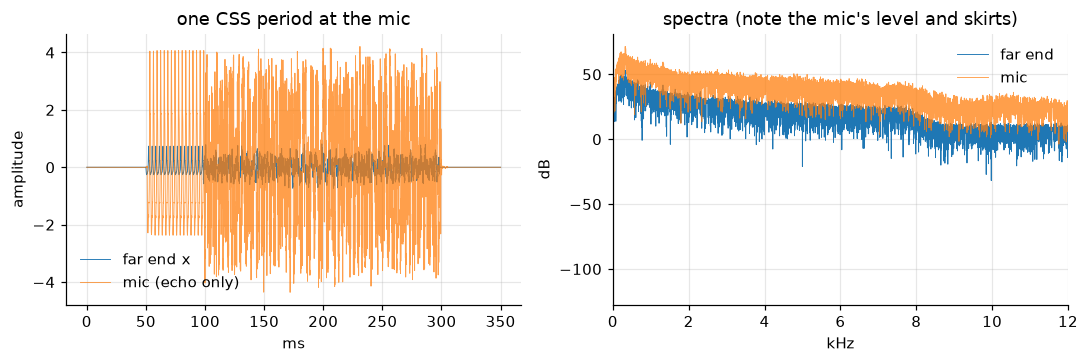

In [2]:
def rms_db(x):
    return 10 * np.log10(np.mean(x**2) + 1e-30)

seg = slice(int(1.0 * FS), int(1.35 * FS))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))
t = np.arange(seg.stop - seg.start) / FS * 1e3
ax1.plot(t, far_end[seg], lw=0.6, label="far end x")
ax1.plot(t, mic[seg], lw=0.6, alpha=0.75, label="mic (echo only)")
ax1.set(xlabel="ms", ylabel="amplitude", title="one CSS period at the mic")
ax1.legend(frameon=False)
n = 1 << 15
w = np.hanning(n)
f = np.fft.rfftfreq(n, 1 / FS)
act = slice(int(4.0 * FS), int(4.0 * FS) + n)
X = 20 * np.log10(np.abs(np.fft.rfft(far_end[act] * w)) + 1e-12)
M = 20 * np.log10(np.abs(np.fft.rfft(mic[act] * w)) + 1e-12)
ax2.plot(f / 1e3, X, lw=0.6, label="far end")
ax2.plot(f / 1e3, M, lw=0.6, alpha=0.75, label="mic")
ax2.set(xlabel="kHz", ylabel="dB", xlim=(0, 12), title="spectra (note the mic's level and skirts)")
ax2.legend(frameon=False)
fig.tight_layout()
erl = rms_db(far_end) - rms_db(mic)
print(f"broadband ERL = {erl:+.1f} dB  (negative = echo louder than reference)")
print("note: broadband ERL is a PROGRAM-WEIGHTED reading — it differs from the path's")
print("nominal scaling by the overlap of the program spectrum with the path's response")
print(f"(here {erl:+.1f} vs a nominal {meta['truth']['erl_db']:+.0f} for a flat path and white program)."
      if "truth" in meta else "")

## 2 — Recipe step 1: the echo path, from the quiet sweep

The sweep is played **below the loudspeaker's knee** (−30 dBm0 here) so
the path measurement is linear; deconvolution is plain regularized
spectral division. **Self-checks a real session can run**: the bulk
delay and the support must fit the preset's short geometry, and the IR
must be stable across two sweep takes. Here we additionally have the
truth IR for a misalignment figure.

Real device: record this sweep through the rig, then commit the IR as a
fixture with `tools/fixtures/make_rir_fixtures.py --from-wav` and
re-pin the path-dependent gates.

**A deconvolved IR is only valid inside the sweep's band** — the cell
below reports accuracy in-band and out-of-band separately, and the
simulated device makes the point sharply: −53 dB in the swept
50 Hz–15 kHz, but −7 dB above 20 kHz where the sweep put no energy
(dragging the *full-band* figure to −19 dB, which is why a single
full-band misalignment number would be the wrong headline). Sweep the
band the deployment actually uses, and band-limit the IR before
committing it as a fixture.

bulk delay ~1.02 ms, 99.9% energy support 1.92 ms; preset filter span 10.7 ms -> FITS
accuracy vs truth: -52.9 dB IN the sweep band (50 Hz-15 kHz), -6.8 dB above 20 kHz, -18.9 dB full band


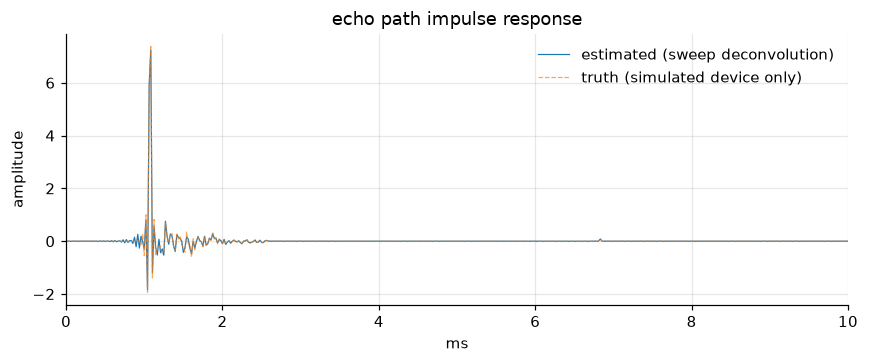

In [3]:
n_fft = 1 << int(np.ceil(np.log2(len(sweep))))
Sw = np.fft.rfft(sweep, n_fft)
Mi = np.fft.rfft(sweep_mic, n_fft)
eps = 1e-6 * np.max(np.abs(Sw))**2
H = Mi * np.conj(Sw) / (np.abs(Sw)**2 + eps)
ir_est = np.fft.irfft(H, n_fft)[: meta["taps"]]

ir_true = load("path_ir.f64") if (DATA / "path_ir.f64").exists() else None
t_ms = np.arange(len(ir_est)) / FS * 1e3
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(t_ms, ir_est, lw=0.8, label="estimated (sweep deconvolution)")
if ir_true is not None:
    ax.plot(t_ms, ir_true, lw=0.8, ls="--", alpha=0.7, label="truth (simulated device only)")
ax.set(xlabel="ms", xlim=(0, 10), ylabel="amplitude", title="echo path impulse response")
ax.legend(frameon=False)
fig.tight_layout()

e = np.cumsum(ir_est**2)
delay_ms = np.argmax(np.abs(ir_est) > 0.05 * np.max(np.abs(ir_est))) / FS * 1e3
support_ms = np.searchsorted(e, 0.999 * e[-1]) / FS * 1e3
span_ms = max(2, int(np.ceil((0.0085 * FS + 1) / BLOCK))) * BLOCK / FS * 1e3
print(f"bulk delay ~{delay_ms:.2f} ms, 99.9% energy support {support_ms:.2f} ms; "
      f"preset filter span {span_ms:.1f} ms -> {'FITS' if support_ms < span_ms else 'DOES NOT FIT: longer path than the outdoor preset assumes'}")
assert support_ms < span_ms
if ir_true is not None:
    mis = 10 * np.log10(np.sum((ir_true - ir_est)**2) / np.sum(ir_true**2))
    fr = np.fft.rfftfreq(n_fft, 1 / FS)
    T, E = np.fft.rfft(ir_true, n_fft), np.fft.rfft(ir_est, n_fft)
    inb = (fr >= 50) & (fr <= 15000)
    oob = fr >= 20000
    err = lambda b: 10 * np.log10(np.sum(np.abs(T[b] - E[b])**2) / np.sum(np.abs(T[b])**2))
    print(f"accuracy vs truth: {err(inb):.1f} dB IN the sweep band (50 Hz-15 kHz), "
          f"{err(oob):.1f} dB above 20 kHz, {mis:.1f} dB full band")

## 3 — Recipe step 2: the loudspeaker nonlinearity, from stepped tones

Harmonic levels are read at each burst level and **referred back
through the measured path** (the IR of §2 evaluated at the fundamental
and its harmonics), giving the loudspeaker's own THD-vs-level curve.
A memoryless model is then fit to that curve. The Stage 2 bake-off's
decision tree turns the fit into a basis choice:

- smooth compressive curve → the shipped `{x³, x⁵}` GS winner stands;
- hard limiting → `clip_difference` at the measured knee;
- a well-fit measured curve → `tanh_difference` at the fitted knee
  (the exactly-representable case: 49.9 dB on-model in the bake-off).

fitted knee 2.65 vs simulated-device truth 2.50


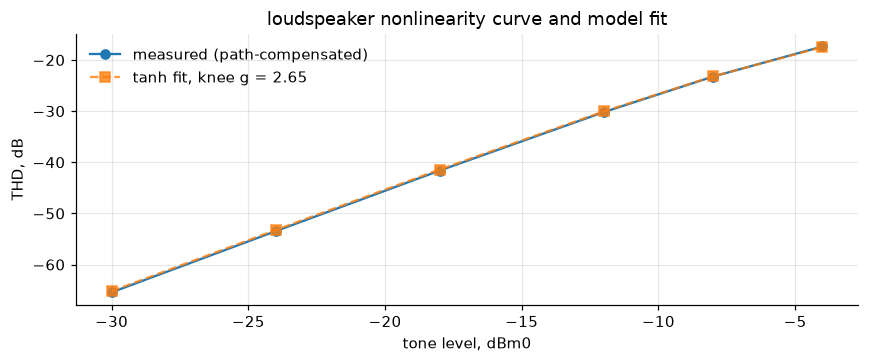

In [4]:
f0 = meta["tone_hz"]
levels = np.array(meta["tone_levels_dbm0"], float)
n_on, n_off = int(0.5 * FS), int(0.25 * FS)
Hf = np.fft.rfft(ir_est, n_fft)
fgrid = np.fft.rfftfreq(n_fft, 1 / FS)
Hmag = lambda f: np.interp(f, fgrid, np.abs(Hf))

def harmonic_levels(x, f0, k_max=5):
    n = 1 << int(np.floor(np.log2(len(x))))
    w = np.hanning(n)
    X = np.abs(np.fft.rfft(x[:n] * w))
    fr = np.fft.rfftfreq(n, 1 / FS)
    out = []
    for k in range(1, k_max + 1):
        band = (fr > k * f0 - 40) & (fr < k * f0 + 40)
        out.append(np.max(X[band]))
    return np.array(out)

thd_meas = []
for i, lvl in enumerate(levels):
    seg = tones_mic[i * (n_on + n_off) + n_on // 4 : i * (n_on + n_off) + n_on]
    h = harmonic_levels(seg, f0)
    h_spk = h / np.array([Hmag(k * f0) for k in range(1, 6)])  # refer back through the path
    thd_meas.append(np.sqrt(np.sum(h_spk[1:]**2)) / h_spk[0])
thd_meas = np.array(thd_meas)

# Fit a memoryless tanh knee to the curve (grid; the model THD is
# computed the same way the measurement is read).
def model_thd(drive, amp):
    t = np.arange(4096) / FS
    y = np.tanh(drive * amp * np.sin(2 * np.pi * f0 * t)) / drive
    h = harmonic_levels(y, f0)
    return np.sqrt(np.sum(h[1:]**2)) / h[0]

amps = 10 ** ((levels - 3.14) / 20) * np.sqrt(2)  # dBm0 -> sine amplitude
grid = np.linspace(0.4, 6.0, 113)
err = [np.sum((np.log10([model_thd(g, a) for a in amps]) - np.log10(thd_meas))**2) for g in grid]
g_fit = grid[int(np.argmin(err))]

fig, ax = plt.subplots(figsize=(8, 3.4))
ax.plot(levels, 20 * np.log10(thd_meas), "o-", label="measured (path-compensated)")
ax.plot(levels, 20 * np.log10([model_thd(g_fit, a) for a in amps]), "s--", alpha=0.8,
        label=f"tanh fit, knee g = {g_fit:.2f}")
ax.set(xlabel="tone level, dBm0", ylabel="THD, dB", title="loudspeaker nonlinearity curve and model fit")
ax.legend(frameon=False)
fig.tight_layout()
truth = meta.get("truth", {})
if "drive" in truth:
    print(f"fitted knee {g_fit:.2f} vs simulated-device truth {truth['drive']:.2f}")
    assert abs(g_fit - truth["drive"]) < 0.3

## 4 — Recipe step 3: branch calibration at the operating plane

The constants come from the **program material at the device's actual
level** through the one documented instrument (LS center against x,
unit-RMS gain of the centered signal, Gram-Schmidt chain between the
finished branch signals — `tests/support/outdoor_scenario.h`). For the
simulated device this must land on the preset's pinned values, and the
same 2 % agreement is what `OutdoorChain.BranchCalibration` gates in CI.

**The audit's warning applies here** (design doc §6.7): the constants
are **level-sensitive** — measured, pinned-at-−10 dBm0 costs ~7 dB at a
−4 dBm0 operating level and ~16 dB at −16 dBm0 against level-matched
recalibration. Calibrate at the level the device will actually play.

In [5]:
def center_and_gain(x, phi):
    c = np.dot(x, phi) / np.dot(x, x)
    p = phi - c * x
    return c, 1.0 / np.sqrt(np.mean(p**2))

x = far_end
c3, g3 = center_and_gain(x, x**3)
c5, g5 = center_and_gain(x, x**5)
e3 = g3 * (x**3 - c3 * x)
e5 = g5 * (x**5 - c5 * x)
chain = np.dot(e5, e3) / np.dot(e3, e3)

pinned = {"c3": 0.19389, "g3": 30.888, "c5": 0.059190, "g5": 57.171, "chain": 0.95740}  # postfilter.h
derived = {"c3": c3, "g3": g3, "c5": c5, "g5": g5, "chain": chain}
print(f"{'':8}{'derived':>12}{'pinned':>12}{'agree':>8}")
for k in pinned:
    ok = abs(derived[k] - pinned[k]) < 0.02 * abs(pinned[k])
    print(f"{k:8}{derived[k]:12.5f}{pinned[k]:12.5f}{'  yes' if ok else '   NO':>8}")
    assert ok, f"{k}: derived constant disagrees with the preset — wrong material or level?"

             derived      pinned   agree
c3           0.19388     0.19389     yes
g3          30.88754    30.88800     yes
c5           0.05919     0.05919     yes
g5          57.17084    57.17100     yes
chain        0.95740     0.95740     yes


## 5 — Recipe step 4: end-to-end verification, real chain via the C ABI

The far-end and mic recordings drive the actual library
(`mutap_aec_create_outdoor`), and the certified indoor chain runs the
same session for contrast. Single talk, so the observable ERLE **is**
the true echo suppression. For the simulated device these numbers must
agree with the gated rows in `tests/test_outdoor.cpp` (moderate drive,
48 kHz: outdoor chain 44.4 dB, certified chain 19.3). On the real
device this section is the acceptance measurement — and the sharper
duplex instrument to add is the AM-FM IMD floor
(`OutdoorChain.DtImdFloor`).

outdoor chain   :  44.4 dB   (gated row: 44.4)
certified chain :  19.3 dB   (gated row: 19.3)


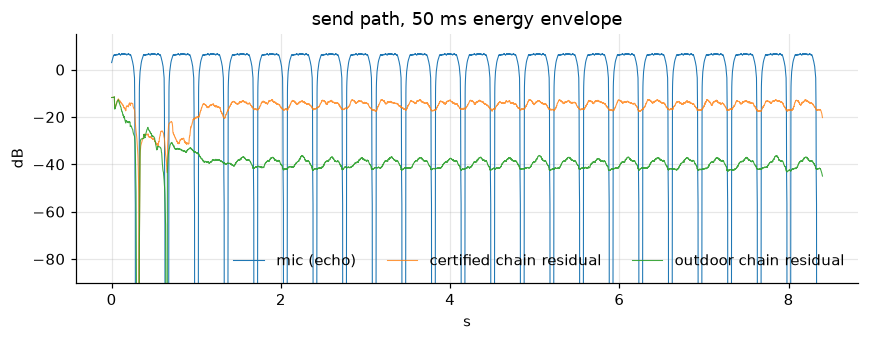

In [6]:
import ctypes
lib = ctypes.CDLL(str(BUILD / "tools" / "capi" / "libmutap_capi.so"))
F64P = ctypes.POINTER(ctypes.c_double)
for name, argt in [("mutap_aec_create_outdoor", [ctypes.c_size_t, ctypes.c_double, ctypes.c_int, ctypes.c_int]),
                   ("mutap_aec_create", [ctypes.c_size_t, ctypes.c_size_t, ctypes.c_double, ctypes.c_int, ctypes.c_int])]:
    getattr(lib, name).restype = ctypes.c_void_p
    getattr(lib, name).argtypes = argt
lib.mutap_aec_process.argtypes = [ctypes.c_void_p, F64P, F64P, F64P]
lib.mutap_aec_destroy.argtypes = [ctypes.c_void_p]

def run_chain(handle, x, y):
    e = np.zeros_like(y)
    b = BLOCK
    for i in range(0, len(x) - len(x) % b, b):
        lib.mutap_aec_process(handle,
                              x[i:i + b].ctypes.data_as(F64P),
                              y[i:i + b].ctypes.data_as(F64P),
                              e[i:i + b].ctypes.data_as(F64P))
    lib.mutap_aec_destroy(handle)
    return e

x64, y64 = np.ascontiguousarray(far_end), np.ascontiguousarray(mic)
e_out = run_chain(lib.mutap_aec_create_outdoor(BLOCK, FS, 1, 1), x64, y64)
e_cert = run_chain(lib.mutap_aec_create(BLOCK, meta["taps"] // BLOCK, FS, 1, 1), x64, y64)

m0 = int(4.0 * FS)
supp = lambda e: 10 * np.log10(np.sum(mic[m0:]**2) / np.sum(e[m0:]**2))
s_out, s_cert = supp(e_out), supp(e_cert)
print(f"outdoor chain   : {s_out:5.1f} dB   (gated row: 44.4)")
print(f"certified chain : {s_cert:5.1f} dB   (gated row: 19.3)")
assert abs(s_out - 44.36) < 2.0 and s_out > s_cert + 15.0

fig, ax = plt.subplots(figsize=(8, 3.2))
w = int(0.05 * FS)
env = lambda s: 10 * np.log10(np.convolve(s**2, np.ones(w) / w, mode="same") + 1e-30)
tt = np.arange(len(mic)) / FS
ax.plot(tt, env(mic), lw=0.7, label="mic (echo)")
ax.plot(tt, env(e_cert), lw=0.7, alpha=0.8, label="certified chain residual")
ax.plot(tt, env(e_out), lw=0.7, alpha=0.9, label="outdoor chain residual")
ax.set(xlabel="s", ylabel="dB", title="send path, 50 ms energy envelope", ylim=(-90, 15))
ax.legend(frameon=False, ncol=3)
fig.tight_layout()

## 6 — When the real device arrives: the checklist

1. **Record the session** with the device's own transducers, same file
   names into one directory: the quiet sweep (+ a repeat take for
   stability), the stepped tones, and ≥ 8 s of the deployment's actual
   program material at its actual playback level. Raw float64 mono at
   the deployment rate. Set `MUTAP_BRINGUP_DATA` and re-run this
   notebook — every section states its self-check.
2. **Commit the measured path** as a fixture
   (`tools/fixtures/make_rir_fixtures.py --from-wav`), and if §2's
   support check fails, the outdoor preset's short-geometry premise is
   wrong for this rig — stop and revisit before tuning anything.
3. **Choose the basis** from §3's curve per the bake-off decision tree,
   and **pin §4's derived constants** into a device preset (an
   `aec_chain_outdoor_preset` variant or a deployment-side config),
   including the device's own `level` plane. Re-pin
   `OutdoorChain.BranchCalibration` against the device material.
4. **Re-measure the battery**: the `test_outdoor.cpp` outdoor-chain
   rows (and `DtImdFloor`) against recordings, not simulation — those
   measured numbers become the device's gates, margins per HANDOFF
   working note 2.
5. **Only then** the learned post-filter: the same recordings seed
   `tools/ml`'s dataset builder for a device-trained `nn_suppressor`
   (Rev 6 follow-up (b)); the number it must move is the DtImdFloor
   (~9 dB of echo IMD above the talker at moderate drive, design doc
   §6.7).

What this recipe deliberately does **not** cover: mic-side overload
(gain staging is a design-time decision — the hard clip guard was
measured and rejected, `MicClipSeverity`), and any in-the-field
adaptation of the calibration constants (the audit's verdict: level is
a control input the device knows, not a statistic to estimate).